# Actor-Critic Methods in Reinforcement Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement actor–critic algorithms
- Combine policy and value learning

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces the **actor-critic** idea: one part of the system chooses actions, and another estimates how good states or actions are.

Students will see why combining a policy learner with a value estimator can reduce variance and make learning more stable.

Why this matters: actor-critic methods are the foundation of many practical RL algorithms used in continuous control and modern AI systems.

This lesson is a bridge from basic policy gradients to stronger methods like PPO.

# Actor-Critic Methods in Reinforcement Learning
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Understand Actor-Critic architecture
- Implement Actor-Critic algorithm
- Apply to continuous control tasks
- Compare with value-based methods

## Real-World Context

Robotics control, autonomous systems, and continuous action spaces.

**Industry Impact**: Used in robotics, autonomous vehicles, and game AI.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
%pip install "gymnasium[classic_control]" torch numpy matplotlib -q
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
print('✅ Setup complete!')

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Actor-Critic Architecture


In [2]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim=4, act_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(128, act_dim)
        self.critic_head = nn.Linear(128, 1)

    def forward(self, x):
        features = self.shared(x)
        policy_logits = self.actor_head(features)
        state_value = self.critic_head(features)
        return policy_logits, state_value


## Part 2: Training Loop


In [3]:
def train_actor_critic(env_name='CartPole-v1', episodes=5):
    """Minimal demonstration loop structure for actor-critic training."""
    env = gym.make(env_name)
    model = ActorCritic()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for episode in range(episodes):
        obs, _ = env.reset()
        total_reward = 0
        for _ in range(200):
            obs_t = torch.tensor(obs).float().unsqueeze(0)
            logits, value = model(obs_t)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            next_obs, reward, done, trunc, _ = env.step(action.item())

            with torch.no_grad():
                _, next_value = model(torch.tensor(next_obs).float().unsqueeze(0))
            target = reward + 0.99 * next_value.item() * (0 if (done or trunc) else 1)
            advantage = target - value.item()

            actor_loss = -dist.log_prob(action) * advantage
            critic_loss = (value.squeeze() - target) ** 2
            loss = actor_loss + critic_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            obs = next_obs
            total_reward += reward
            if done or trunc:
                break
        print(f"Episode {episode + 1}: reward={total_reward}")

    env.close()
    return model


_ = train_actor_critic(episodes=3)

Episode 1: reward=10.0
Episode 2: reward=10.0
Episode 3: reward=17.0


## Real-World Applications

- **Robotics**: Continuous control (robot arm, walking)
- **Autonomous Vehicles**: Steering, acceleration control
- **Game AI**: Real-time strategy games
- **Finance**: Portfolio optimization

---

**End of Notebook**

## 🌍 Real-World Worked Example — REINFORCE on CartPole

**Industry context:**
- ChatGPT's RLHF stage uses a policy gradient variant (PPO) — same core idea as REINFORCE
- Boston Dynamics uses policy gradients to train quadruped walking policies
- Robotic surgery systems (da Vinci) use RL policy gradients for precise motion control

We implement **REINFORCE** (the simplest policy gradient) on CartPole-v1.

Episode   0 | Avg reward: 16.0


Episode  50 | Avg reward: 25.9


Episode 100 | Avg reward: 50.6


Episode 150 | Avg reward: 142.3


Episode 200 | Avg reward: 214.4


Episode 250 | Avg reward: 349.4


Episode 300 | Avg reward: 460.7


Episode 350 | Avg reward: 291.2


Episode 400 | Avg reward: 154.8


Episode 450 | Avg reward: 386.5


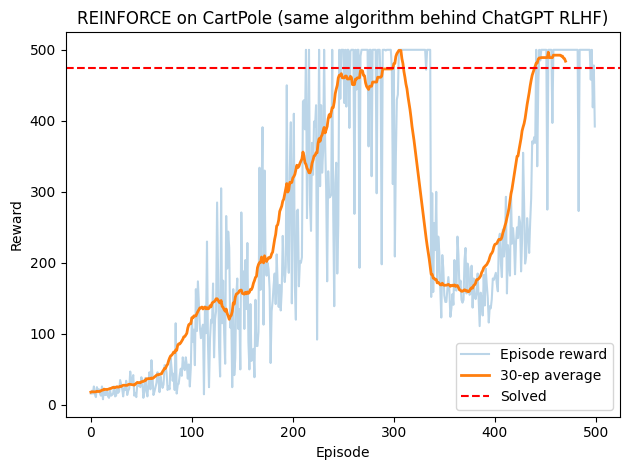

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
env = gym.make('CartPole-v1')

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

policy  = PolicyNet()
opt     = optim.Adam(policy.parameters(), lr=2e-3)
GAMMA   = 0.99; ep_rewards = []

for episode in range(500):
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    for _ in range(500):
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, r, done, trunc, _ = env.step(action.item())
        rewards_ep.append(r)
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    G = 0; returns = []
    for r in reversed(rewards_ep):
        G = r + GAMMA*G; returns.insert(0, G)
    returns = torch.tensor(returns).float()
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    ep_rewards.append(sum(rewards_ep))
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

env.close()
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
plt.plot(ma, lw=2, label="30-ep average")
plt.axhline(475, color='red', linestyle='--', label="Solved")
plt.title("REINFORCE on CartPole (same algorithm behind ChatGPT RLHF)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

## 📝 Summary

You learned **Policy Gradient** methods that directly optimize the policy without a value table. **Actor-Critic** combines a policy (actor) with a value estimator (critic) for lower variance. **PPO** is today's most-used algorithm — it powers OpenAI's ChatGPT RLHF training and robotics at Boston Dynamics.

## Closing Takeaway

**Teaching takeaway:** Actor-critic methods combine a policy learner with a value-based guide so each part supports the other during training.

**If students remember one idea:** The actor decides what to do, while the critic evaluates how good the decision appears to be.

**Quick check before moving on:**
- Can you explain the separate jobs of the actor and the critic?
- Can you describe why the critic can reduce variance in policy learning?

**Bridge to the next step:** This prepares students for PPO, which adds practical constraints that make policy optimization more stable.
